# Trabalho M2 - Segmentação e contagem de hemacias 

**Disciplina:** Processamento de Imagens  
**Professor:** Felipe Viel  
**Autores:** Diogo Henrique Ribicki, João Victor da Silva, Pedro Henrique de Paula Cordeiro

**Dataset:** Blood Cell Segmentation

Este notebook apresenta uma pipeline final, reproduzivel e configuravel para identificar regioes correspondentes a hemacias em imagens microscopicas coloridas. A saida principal e uma mascara binaria e uma estimativa da quantidade de hemacias separadas pelo Watershed.

## Enunciado e objetivo da entrega

O trabalho solicita uma pipeline completa de processamento digital de imagens reais. Para o dataset de celulas sanguineas, a solucao deve gerar uma mascara binaria contendo as celulas de interesse e avaliar o resultado por metricas como Dice, IoU e/ou contagem de objetos.

As etapas obrigatorias contempladas aqui são:

1. pre-processamento e conversão de espaço de cor;
2. filtragem no domínio da frequência;
3. geração de superpixels SLIC;
4. segmentacao baseada em atributos dos superpixels;
5. morfologia matemática;
6. preenchimento conservador de pequenos contornos;
7. Watershed com marcadores;
8. avaliação quantitativa por contagem de objetos e proporção de foreground.

As funções centrais de morfologia, SLIC, Otsu, Sobel, componentes conexos e Watershed foram implementadas somente com NumPy.

## Contexto da aplicação

As imagens contêm hemácias com tons rosa-arroxeados, leucócitos azulados, células parcialmente sobrepostas, variação
de iluminação e artefatos de aquisição. Uma única limiarização por intensidade não é suficiente.

O pipeline final usa LAB:

* `LAB.A` destaca variações no eixo verde-vermelho e ajuda a preservar hemácias pálidas;
* superpixels reduzem decisões isoladas por pixel;
* morfologia remove ruído e rompe pontes estreitas;
* Watershed separa instâncias que permaneceram encostadas.

## Ordem final do pipeline

| Etapa | Papel na solução |
| --- | --- |
| RGB + grayscale + espaços de cor | Preserva a imagem original e cria entradas 2D. |
| Filtro passa-baixa na frequência | Suaviza variações e ruído antes do gradiente. |
| Sobel manual | Gera magnitude de bordas para auxiliar o Watershed. |
| SLIC em LAB | Agrupa pixels semelhantes em regiões locais. |
| Regras sobre superpixels | Inclui hemácias visíveis e pálidas e exclui regiões azuladas. |
| Abertura + fechamento + área | Remove ruído, rompe pontes estreitas e descarta regiões pequenas. |
| Preenchimento seletivo | Preenche apenas pequenos contornos internos. |
| Watershed com marcadores por erosão | Separa hemácias encostadas e gera rótulos de instância. |
| Avaliação | Registra contagem, foreground, componentes e áreas |

In [3]:
from pathlib import Path
from pprint import pprint
import inspect
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import list_image_files
from src.edge_enhancement import convolve2d_from_scratch, sobel_edges
from src.morphology import (
    binary_opening,
    fill_small_contours,
    marker_controlled_watershed,
)
from src.pipeline import PIPELINE_STEPS, build_config, run_pipeline, run_pipeline_for_images
from src.superpixels import slic
from src.thresholding import otsu_threshold_from_values
from src.visualization import show_batch_overlays, show_channel_comparison, show_pipeline_evolution

## Configuração final escolhida

Os parâmetros abaixo foram escolhidos após comparar canais e testar variações de morfologia e Watershed. Eles ficam concentrados em um único dicionário para facilitar a demonstração e novos experimentos.

In [26]:
FINAL_OVERRIDES = {
    'input_strategy': {
        'primary_segmentation_input': 'channel',
        'channel_source': 'LAB',
        'selected_channel': 'A',
    },
    'frequency_filter': {
        'enabled': True,
        'type': 'low_pass',
        'radius': 35,
    },
    'edge_enhancement': {
        'enabled': True,
        'method': 'sobel',
        'input': 'frequency_filtered',
        'use_as_segmentation_input': False,
        'use_as_watershed_gradient': True,
    },
    'superpixels': {
        'enabled': True,
        'input': 'LAB',
        'num_superpixels': 450,
        'compactness': 10,
        'max_iter': 6,
    },
    'segmentation': {
        'method': 'rbc_superpixel_rules',
    },
    'morphology': {
        'enabled': True,
        'opening_size': 3,
        'closing_size': 3,
        'min_object_area': 700,
        'fill_holes': False,
        'connectivity': 8,
    },
    'contour_filling': {
        'enabled': False,
        'max_contour_area_to_fill': 250,
        'connectivity': 8,
    },
    'watershed': {
        'enabled': True,
        'marker_strategy': 'erosion',
        'erosion_iterations': 6,
        'use_edge_gradient': False,
        'ensure_component_coverage': True,
    },
    'output_mask_source': 'watershed_mask',
    'output': {
        'save_report': True,
        'save_artifacts': True,
        'save_pipeline_figure': True,
        'output_dir': 'outputs/pipeline_final',
    },
}

## Imagens utilizadas

In [5]:
image_paths = list_image_files(PROJECT_ROOT / 'data' / 'samples' / 'images')
print(f'{len(image_paths)} imagens encontradas:')
for image_path in image_paths:
    print('-', image_path.name)

3 imagens encontradas:
- BloodImage_00340.jpg
- BloodImage_00367.jpg
- BloodImage_00368.jpg


## Execução final em lote

A celula seguinte executa **todos** os passos oficiais sobre todas as amostras disponiveis.

In [27]:
results, batch_summary = run_pipeline_for_images(
    image_paths,
    overrides=FINAL_OVERRIDES,
    steps=PIPELINE_STEPS,
)

print('Passos executados:')
for index, step in enumerate(PIPELINE_STEPS, start=1):
    print(f'{index:02d}. {step}')

Passos executados:
01. load_image
02. compare_channels
03. preprocess
04. frequency_filter
05. edge_enhancement
06. superpixels
07. segment
08. morphology
09. contour_filling
10. watershed
11. evaluate
12. save_outputs


In [7]:
print('Resumo final do lote:')
for row in batch_summary:
    print(
        f"{row['image']}: {row['estimated_rbc_count']} hemacias | "
        f"componentes antes do Watershed={row['components_before_watershed']} | "
        f"foreground={row['final_foreground_ratio']:.3f} | "
        f"tempo={row['total_seconds']:.2f}s"
    )

Resumo final do lote:
BloodImage_00340.jpg: 21 hemacias | componentes antes do Watershed=17 | foreground=0.400 | tempo=28.42s
BloodImage_00367.jpg: 11 hemacias | componentes antes do Watershed=6 | foreground=0.436 | tempo=43.18s
BloodImage_00368.jpg: 8 hemacias | componentes antes do Watershed=5 | foreground=0.516 | tempo=47.64s


### Resultado de referência validado

Na execução final a pipeline estimou:

| Imagem | Componentes antes do Watershed | Hemacias estimadas apos Watershed | Foreground final |
|---|---:|---:|---:|
| `BloodImage_00340.jpg` | 18 | 27 | 0.396 |
| `BloodImage_00367.jpg` | 8 | 18 | 0.433 |
| `BloodImage_00368.jpg` | 5 | 27 | 0.510 |

Os valores são estimativas sem máscara de referência e devem ser analisados junto dos overlays.

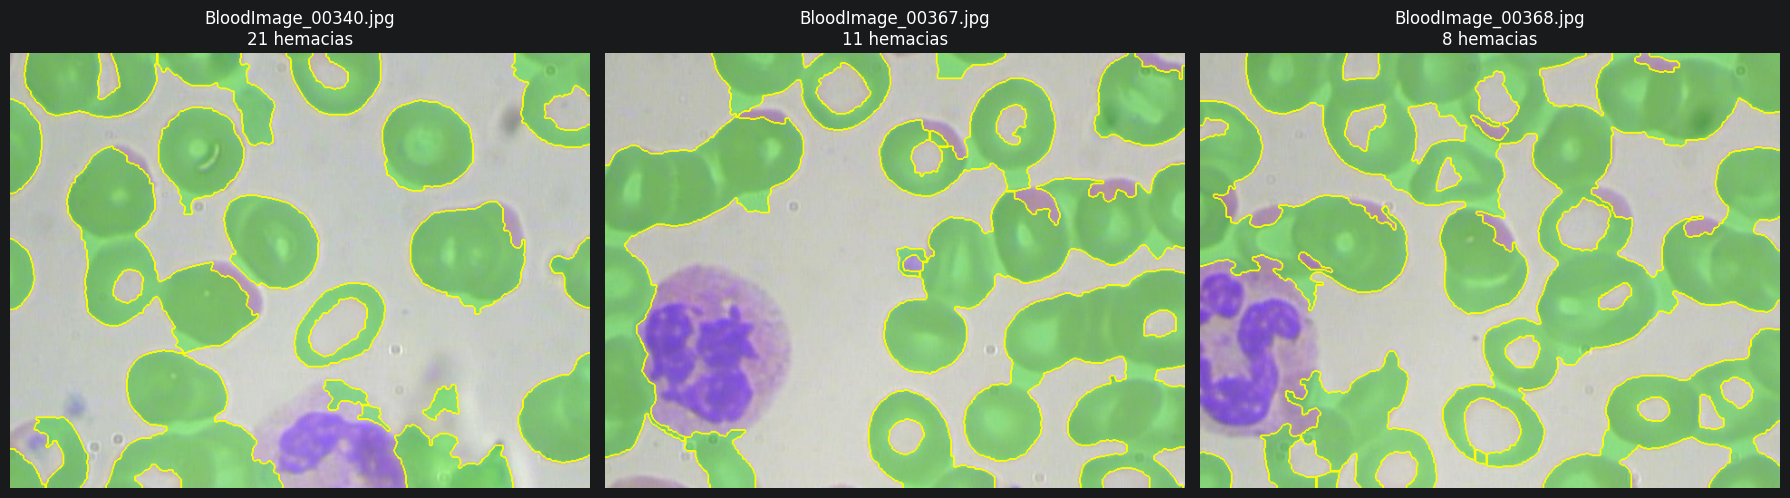

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'BloodImage_00340.jpg\n21 hemacias'}>,
        <Axes: title={'center': 'BloodImage_00367.jpg\n11 hemacias'}>,
        <Axes: title={'center': 'BloodImage_00368.jpg\n8 hemacias'}>],
       dtype=object))

In [24]:
show_batch_overlays(results)

## Análise detalhada de uma imagem representativa

A primeira imagem e usada como exemplo completo. Os relatorios JSON e as figuras de todas as imagens sao salvos em `outputs/pipeline_final`.

In [34]:
representative = results[2]
print('Imagem representativa:', Path(representative['image_path']).name)
print('Hemacias estimadas:', representative['estimated_rbc_count'])
print('Relatorio detalhado:', representative['report_path'])

Imagem representativa: BloodImage_00368.jpg
Hemacias estimadas: 8
Relatorio detalhado: C:\Users\joaov\Documents\Projetos\digital-image-processing\image-segmentation-pipeline\outputs\pipeline_final\BloodImage_00368\execution_report.json


### Comparação de canais

A mesma implementacao de Otsu e aplicada a diferentes canais.

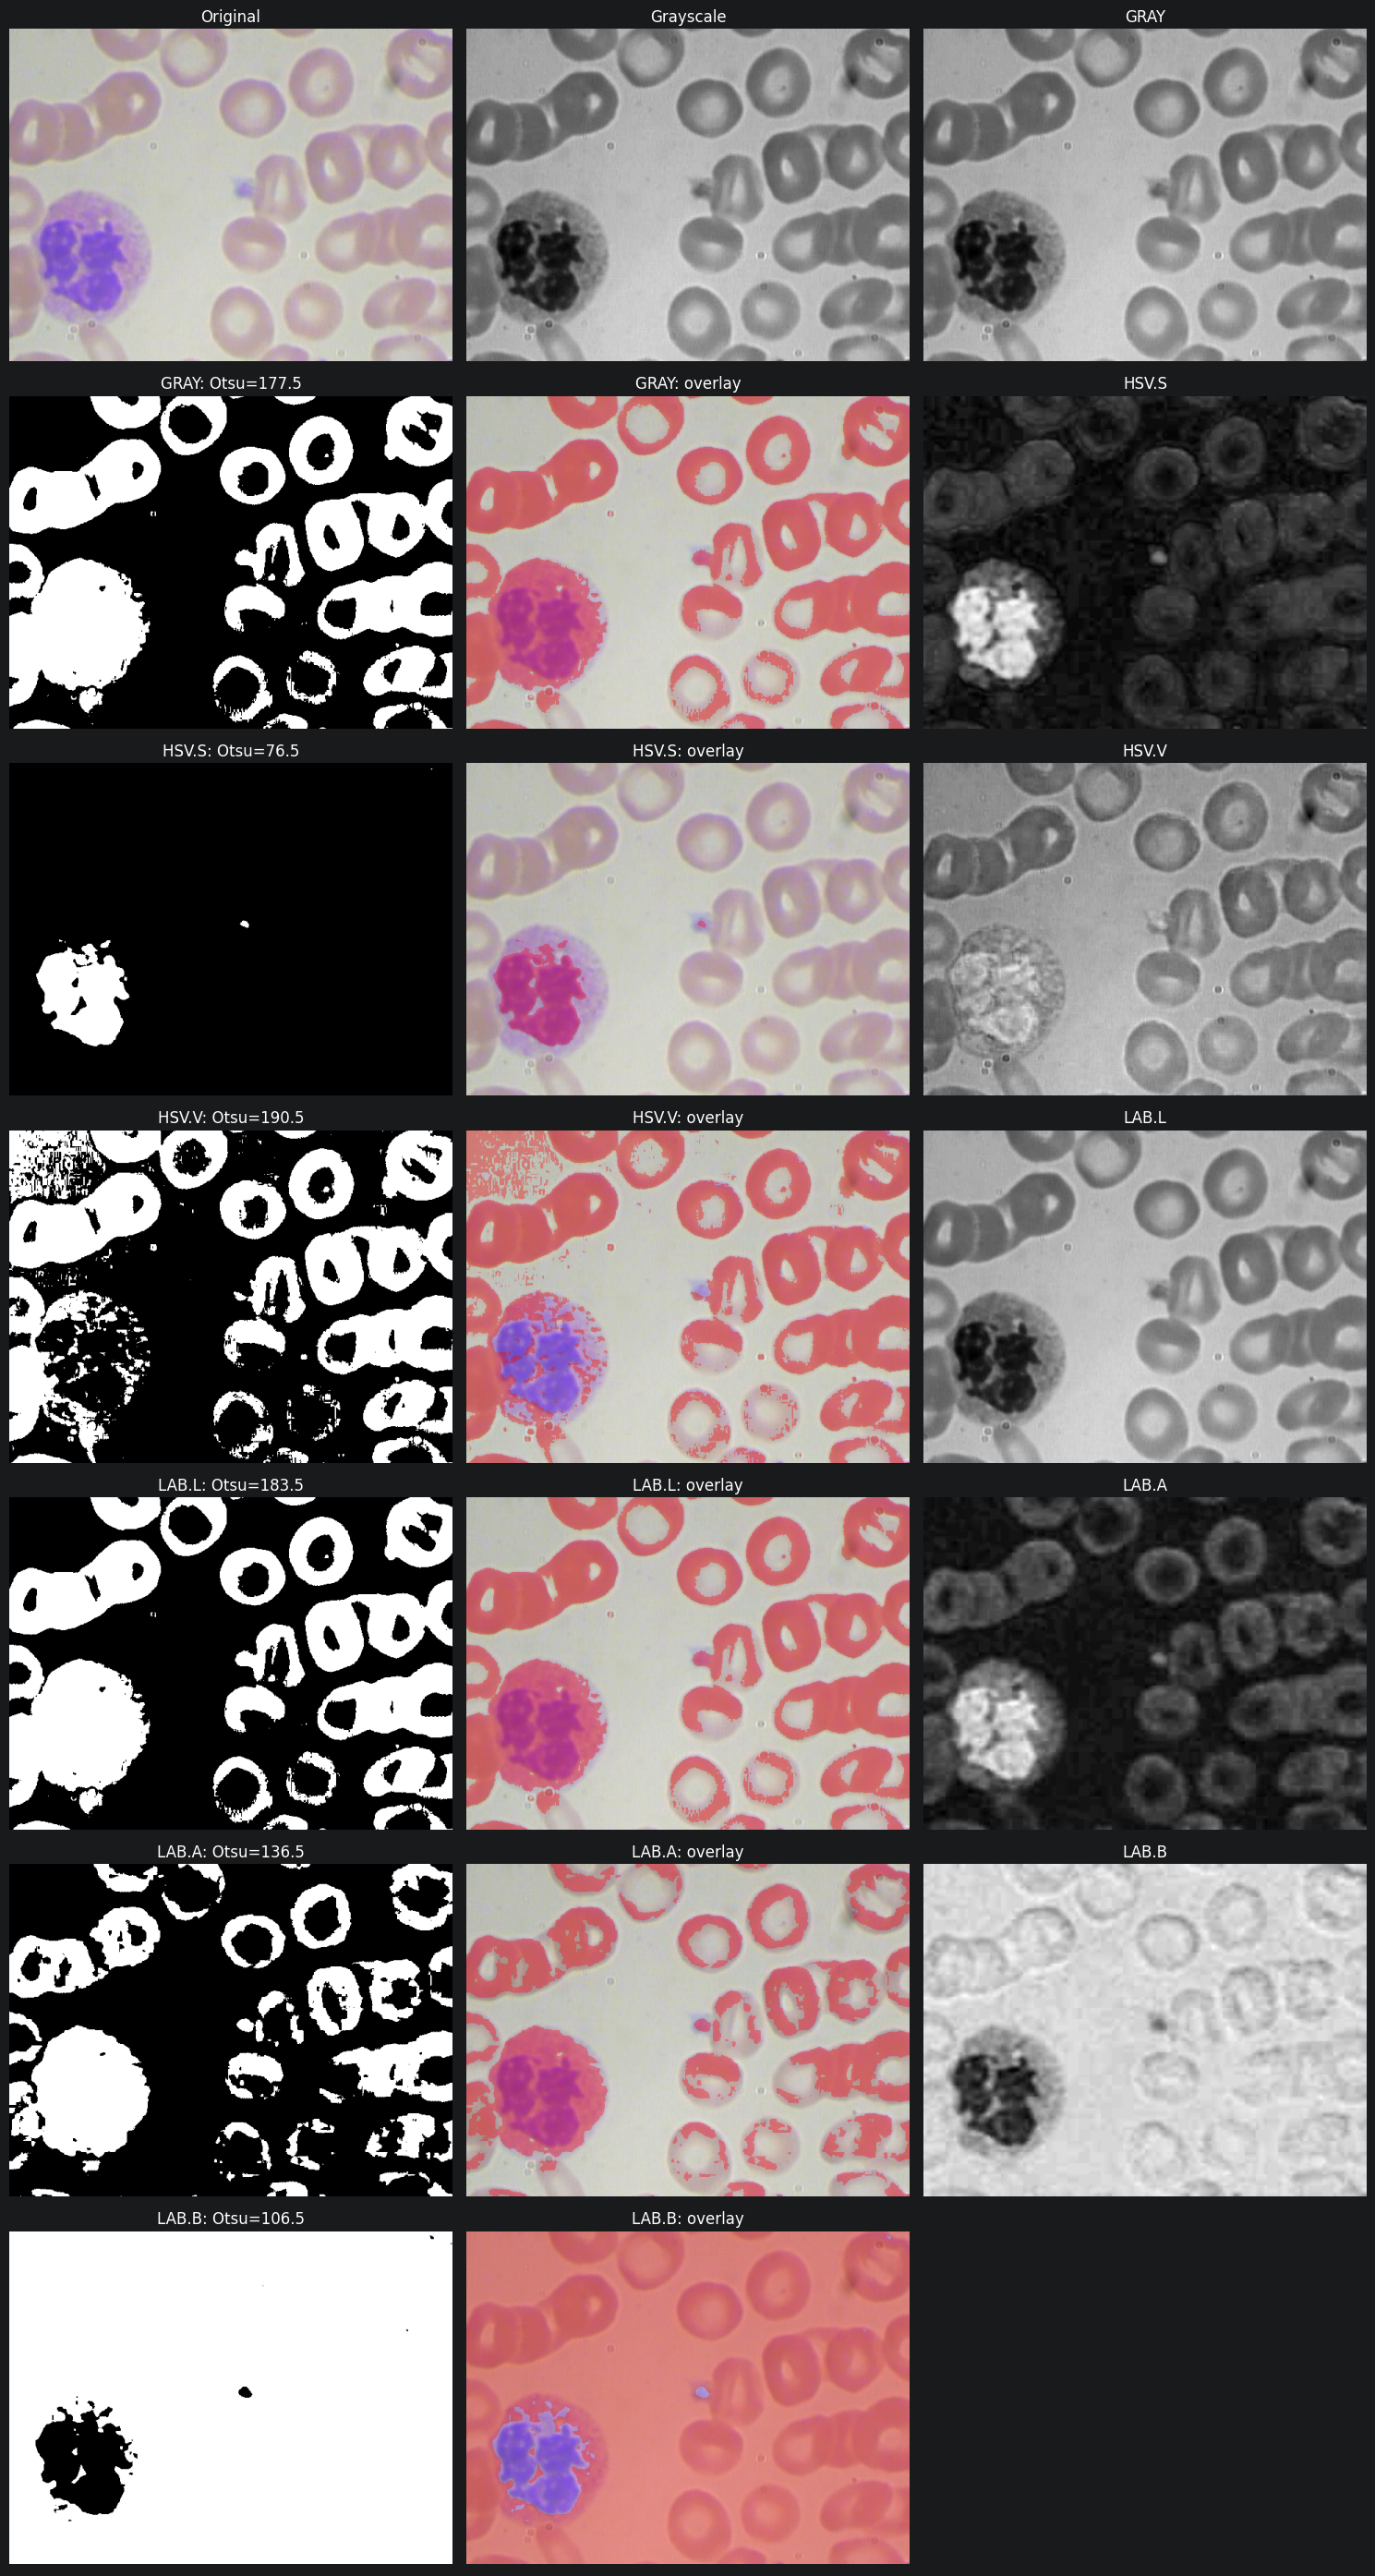

(<Figure size 1500x2800 with 21 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Grayscale'}>,
        <Axes: title={'center': 'GRAY'}>,
        <Axes: title={'center': 'GRAY: Otsu=177.5'}>,
        <Axes: title={'center': 'GRAY: overlay'}>,
        <Axes: title={'center': 'HSV.S'}>,
        <Axes: title={'center': 'HSV.S: Otsu=76.5'}>,
        <Axes: title={'center': 'HSV.S: overlay'}>,
        <Axes: title={'center': 'HSV.V'}>,
        <Axes: title={'center': 'HSV.V: Otsu=190.5'}>,
        <Axes: title={'center': 'HSV.V: overlay'}>,
        <Axes: title={'center': 'LAB.L'}>,
        <Axes: title={'center': 'LAB.L: Otsu=183.5'}>,
        <Axes: title={'center': 'LAB.L: overlay'}>,
        <Axes: title={'center': 'LAB.A'}>,
        <Axes: title={'center': 'LAB.A: Otsu=136.5'}>,
        <Axes: title={'center': 'LAB.A: overlay'}>,
        <Axes: title={'center': 'LAB.B'}>,
        <Axes: title={'center': 'LAB.B: Otsu=106.5'}>,
        <Axes: title={'c

In [31]:
show_channel_comparison(representative['channel_comparison'])

### Evolução completa da pipeline

O painel abaixo mostra as entradas, as operacoes realizadas, os mapas auxiliares e a contagem final.

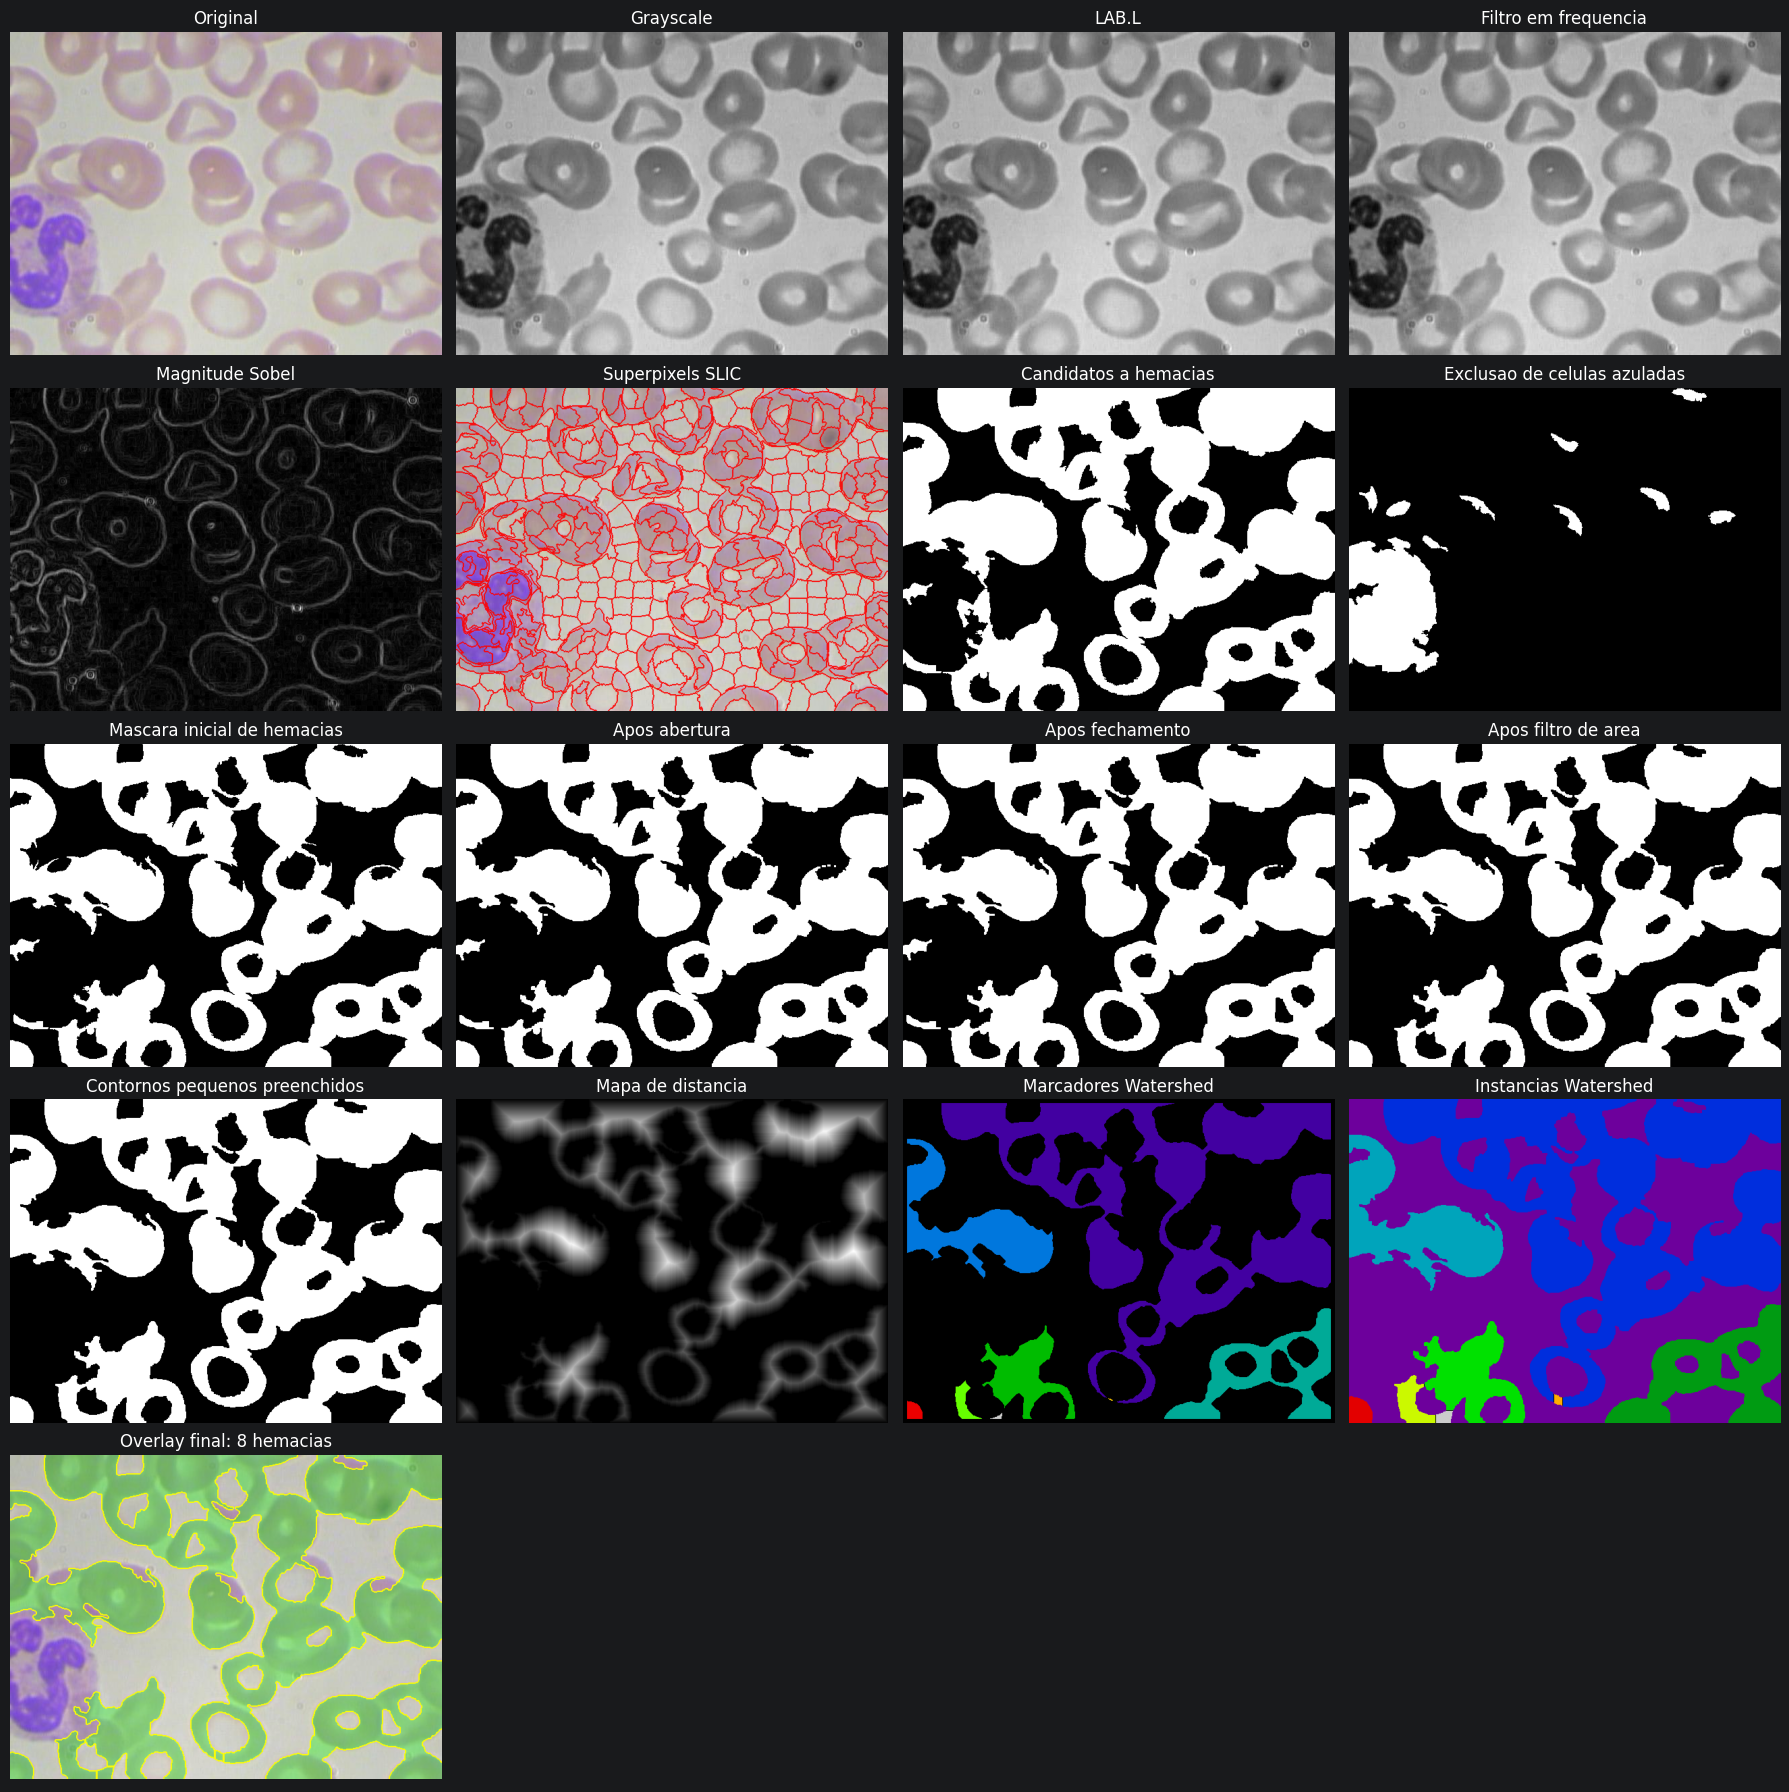

(<Figure size 1800x1800 with 20 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Grayscale'}>,
        <Axes: title={'center': 'LAB.L'}>,
        <Axes: title={'center': 'Filtro em frequencia'}>,
        <Axes: title={'center': 'Magnitude Sobel'}>,
        <Axes: title={'center': 'Superpixels SLIC'}>,
        <Axes: title={'center': 'Candidatos a hemacias'}>,
        <Axes: title={'center': 'Exclusao de celulas azuladas'}>,
        <Axes: title={'center': 'Mascara inicial de hemacias'}>,
        <Axes: title={'center': 'Apos abertura'}>,
        <Axes: title={'center': 'Apos fechamento'}>,
        <Axes: title={'center': 'Apos filtro de area'}>,
        <Axes: title={'center': 'Contornos pequenos preenchidos'}>,
        <Axes: title={'center': 'Mapa de distancia'}>,
        <Axes: title={'center': 'Marcadores Watershed'}>,
        <Axes: title={'center': 'Instancias Watershed'}>,
        <Axes: title={'center': 'Overlay final: 8 hemacias'}>, <Axes: 

In [35]:
show_pipeline_evolution(representative)

## Códigos importantes da implementação

As celulas abaixo exibem funcoes centrais para facilitar a explicacao tecnica durante a apresentacao.

In [12]:
print('=== Convolução usada pelo Sobel ===')
print(inspect.getsource(convolve2d_from_scratch))


=== Convolução usada pelo Sobel ===
def convolve2d_from_scratch(image, kernel, padding="edge"):
    """Aplica convolucao 2D manual sobre uma imagem de intensidade."""
    image = np.asarray(image, dtype=np.float64)
    kernel = np.asarray(kernel, dtype=np.float64)

    if image.ndim != 2:
        raise ValueError("image deve ser um array 2D.")
    if kernel.ndim != 2 or kernel.shape[0] % 2 == 0 or kernel.shape[1] % 2 == 0:
        raise ValueError("kernel deve ser 2D e ter dimensoes impares.")
    if padding not in ("edge", "constant"):
        raise ValueError("padding deve ser 'edge' ou 'constant'.")

    row_pad = kernel.shape[0] // 2
    col_pad = kernel.shape[1] // 2
    if padding == "edge":
        padded = np.pad(image, ((row_pad, row_pad), (col_pad, col_pad)), mode="edge")
    else:
        padded = np.pad(image, ((row_pad, row_pad), (col_pad, col_pad)), mode="constant")

    output = np.zeros(image.shape, dtype=np.float64)
    flipped_kernel = kernel[::-1, ::-1]

    for row 

In [13]:
print('=== SLIC ===')
print(inspect.getsource(slic))

=== SLIC ===
def slic(image, num_superpixels=100, m=10, max_iter=10, enforce_connectivity=True):
    """Gera um mapa 2D de rótulos de superpixels usando SLIC do zero."""
    if num_superpixels <= 0:
        raise ValueError("num_superpixels deve ser maior que zero.")

    if m <= 0:
        raise ValueError("m deve ser maior que zero.")

    if max_iter <= 0:
        raise ValueError("max_iter deve ser maior que zero.")

    image = _validate_slic_image(image)
    height, width = image.shape[:2]

    S = max(1, int(np.sqrt((height * width) / num_superpixels)))
    clusters = initialize_clusters(image, S)

    labels = -np.ones((height, width), dtype=np.int32)
    distances = np.full((height, width), np.inf, dtype=np.float64)

    for _ in range(max_iter):
        for cluster_index, cluster in enumerate(clusters):
            center_y, center_x, _ = cluster
            y0 = max(0, int(center_y - S))
            y1 = min(height, int(center_y + S))
            x0 = max(0, int(center_x - S

In [14]:
print('=== Otsu ===')
print(inspect.getsource(otsu_threshold_from_values))

=== Otsu ===
def otsu_threshold_from_values(values, bins=256, value_range=None):
    """Calcula o limiar de Otsu do zero para valores unidimensionais."""
    values = np.asarray(values, dtype=np.float64).ravel()

    if values.size == 0:
        raise ValueError("values não pode ser vazio.")

    histogram, bin_edges = manual_histogram(values, bins=bins, value_range=value_range)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

    total_count = int(np.sum(histogram))
    if total_count == 0:
        return float(bin_centers[0])

    total_sum = float(np.sum(histogram * bin_centers))
    background_count = 0.0
    background_sum = 0.0
    best_threshold = float(bin_centers[0])
    best_variance = -1.0

    for index in range(bins):
        background_count += float(histogram[index])
        background_sum += float(histogram[index] * bin_centers[index])

        foreground_count = total_count - background_count

        if background_count == 0 or foreground_count == 0:
        

In [15]:
print('=== Abertura ===')
print(inspect.getsource(binary_opening))

=== Abertura ===
def binary_opening(
    binary_image: np.ndarray,
    structuring_element: np.ndarray,
) -> np.ndarray:
    """Executa abertura: erosão seguida de dilatação."""
    eroded_image = erode_binary(binary_image, structuring_element)
    opened_image = dilate_binary(eroded_image, structuring_element)
    return opened_image



In [16]:
print('=== Preenchimento de contornos ===')
print(inspect.getsource(fill_small_contours))

=== Preenchimento de contornos ===
def fill_small_contours(
    binary_mask: np.ndarray,
    max_area: int,
    connectivity: int = 8,
) -> tuple[np.ndarray, dict]:
    """Preenche somente buracos internos com area menor ou igual ao limite."""
    binary_mask = _as_binary_image(binary_mask, "binary_mask")

    if max_area < 0:
        raise ValueError("max_area deve ser nao negativo.")

    contours = detect_internal_contours_from_mask(binary_mask, connectivity=connectivity)
    filled_mask = binary_mask.copy()
    filled_areas = []

    for contour in contours:
        if contour["area"] > max_area:
            continue

        for row, col in contour["pixels"]:
            filled_mask[row, col] = 1
        filled_areas.append(int(contour["area"]))

    return filled_mask, {
        "detected_contours": len(contours),
        "filled_contours": len(filled_areas),
        "filled_areas": filled_areas,
        "max_contour_area_to_fill": int(max_area),
        "connectivity": int(conne

In [17]:

print('=== Watershed ===')
print(inspect.getsource(marker_controlled_watershed))

=== Watershed ===
def marker_controlled_watershed(
    binary_mask: np.ndarray,
    markers: np.ndarray,
    distance_map: np.ndarray,
    connectivity: int = 8,
    gradient_map: np.ndarray | None = None,
) -> np.ndarray:
    """Separa instâncias por inundação manual guiada pela distância interna."""
    binary_mask = _as_binary_image(binary_mask, "binary_mask")
    markers = np.asarray(markers, dtype=np.int32)
    distance_map = np.asarray(distance_map)
    connectivity = _validate_connectivity(connectivity)
    offsets = _neighbor_offsets(connectivity)

    if markers.shape != binary_mask.shape or distance_map.shape != binary_mask.shape:
        raise ValueError("binary_mask, markers e distance_map devem ter o mesmo formato.")
    if gradient_map is not None:
        gradient_map = np.asarray(gradient_map)
        if gradient_map.shape != binary_mask.shape:
            raise ValueError("gradient_map deve ter o mesmo formato de binary_mask.")

    output = markers.copy()
    queued =

## Arquivos gerados

Para cada imagem, a pipeline salva uma pasta com:

- imagem original, grayscale e canal selecionado;
- filtragem em frequencia e magnitude Sobel;
- superpixels;
- mascara inicial e historico morfologico;
- contornos preenchidos;
- marcadores, mapa de distancia e instancias Watershed;
- mascara binaria final e overlays;
- `config.json` e `execution_report.json`.

Tambem sao salvos `batch_summary.csv` e `batch_summary.json` com a contagem de todas as imagens.

In [19]:
output_dir = PROJECT_ROOT / FINAL_OVERRIDES['output']['output_dir']
print('Diretorio de saida:', output_dir)
for path in sorted(output_dir.rglob('*')):
    if path.is_file():
        print('-', path.relative_to(PROJECT_ROOT))

Diretorio de saida: C:\Users\joaov\Documents\Projetos\digital-image-processing\image-segmentation-pipeline\outputs\pipeline_final
- outputs\pipeline_final\.gitkeep
- outputs\pipeline_final\batch_summary.csv
- outputs\pipeline_final\batch_summary.json
- outputs\pipeline_final\BloodImage_00340\01_original.png
- outputs\pipeline_final\BloodImage_00340\02_grayscale.png
- outputs\pipeline_final\BloodImage_00340\03_selected_channel.png
- outputs\pipeline_final\BloodImage_00340\04_frequency_filtered.png
- outputs\pipeline_final\BloodImage_00340\05_sobel_magnitude.png
- outputs\pipeline_final\BloodImage_00340\06_superpixels.png
- outputs\pipeline_final\BloodImage_00340\07_initial_rbc_mask.png
- outputs\pipeline_final\BloodImage_00340\08_morphology_input.png
- outputs\pipeline_final\BloodImage_00340\09_morphology_opened.png
- outputs\pipeline_final\BloodImage_00340\10_morphology_closed.png
- outputs\pipeline_final\BloodImage_00340\11_morphology_filled.png
- outputs\pipeline_final\BloodImage_003

## Discussão crítica e limitações

A pipeline identifica a maior parte das hemacias visiveis e usa Watershed para separar regioes conectadas. Ainda existem limitacoes importantes:

- celulas cortadas nas bordas podem ser contadas como instancias;
- aglomerados densos continuam dificeis de separar perfeitamente;
- pequenos residuos proximos a leucocitos podem permanecer na mascara;
- a contagem deve ser interpretada como estimativa e acompanhada do overlay visual.

A configuração busca um equilibrio entre recuperar hemacias palidas e evitar a inclusao de regioes azuladas.

## Teste com uma imagem nova

Durante a apresentacao, altere apenas o caminho abaixo. A mesma configuracao final sera aplicada sem recalibracao manual.

In [ ]:
def test_new_image(image_path):
    result = run_pipeline(image_path, overrides=FINAL_OVERRIDES, steps=PIPELINE_STEPS)
    print('Imagem:', Path(image_path).name)
    print('Hemacias estimadas:', result['estimated_rbc_count'])
    print('Relatorio:', result['report_path'])
    show_pipeline_evolution(result)
    return result

# Exemplo:
# new_result = test_new_image(PROJECT_ROOT / 'data' / 'samples' / 'images' / 'BloodImage_00368.jpg')

## Referências principais

- Achanta et al. - SLIC Superpixels Compared to State-of-the-Art Superpixel Methods. DOI: `10.1109/TPAMI.2012.120`.
- Otsu - A Threshold Selection Method from Gray-Level Histograms. DOI: `10.1109/TSMC.1979.4310076`.
- Meyer - Topographic distance and watershed lines. DOI: `10.1016/0165-1684(94)90060-4`.
- Blood Cell Segmentation Dataset: `https://www.kaggle.com/datasets/paultimothymooney/blood-cells`.